# Importar as bibliotecas necessárias
- Como **pandas**: utilizado para ler o arquivo CSV da telemetria.
- Como **numpy**: utilizado para operações matemáticas.
- Como **matplotlib.pyplot**: utlilizado para plotar os gráficos dos dados.
- Como **Rocketpy**: utilizado para simular a trajetória do foguete.

In [2]:
# Tenta importar as bibliotecas
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import rocketpy
    print("✅ Sucesso! Todas as bibliotecas estão instaladas.")
except ImportError as e:
    # Se der erro, ele avisa qual falta e explica como instalar
    print(f"❌ Falta uma biblioteca: {e.name}")
    print("Tentando instalar automaticamente...")
    
    # Comando mágico para instalar direto pelo notebook
    # O "!" diz para o notebook rodar um comando de terminal
    !pip install pandas numpy matplotlib rocketpy scipy
    
    print("Instalação concluída. Por favor, reinicie o Kernel (Kernel -> Restart) e tente novamente.")

✅ Sucesso! Todas as bibliotecas estão instaladas.


### Leitura do arquivo CSV da telemetria.
- Como no arquivo está sendo usado a ',' para separar os decimais, é necessário fazer essa alteração.

In [4]:
# Carrega o arquivo avisando ao Python que o decimal é vírgula
df = pd.read_csv('nashira_telemetry.csv', decimal=',')

# Mostra as 5 primeiras linhas para conferir se deu certo
display(df.head())

# Mostra informações sobre as colunas (para garantir que são números 'float' e não texto 'object')
df.info()

,timestamp_ms,gnss_time,lat,lon,alt_gps,gnss_fix,gnss_sats,alt_bar,pressure,temperature,...,mag_y,mag_z,roll,pitch,yaw,flight_state,imu_valid,ekf_valid,bar_valid,attitude_reliable
0,25489,NaN,0.0,0.0,0.0,0,0,463.39,958.82,31.04,...,9.3407,62.1313,-3.97,-13.40,-153.59,1,NaN,NaN,NaN,NaN
1,25529,NaN,0.0,0.0,0.0,0,0,463.39,958.82,31.04,...,8.6099,62.6140,-4.04,-13.43,-153.98,1,NaN,NaN,NaN,NaN
2,25628,NaN,0.0,0.0,0.0,0,0,463.39,958.82,31.04,...,8.0377,62.7290,-4.13,-13.46,-154.50,1,NaN,NaN,NaN,NaN
3,25728,NaN,0.0,0.0,0.0,0,0,463.39,958.82,31.04,...,7.3980,61.8057,-4.19,-13.48,-154.98,1,NaN,NaN,NaN,NaN
4,25828,NaN,0.0,0.0,0.0,0,0,463.39,958.82,31.04,...,8.7527,61.9849,-4.28,-13.44,-155.25,1,NaN,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 3554 entries, 0 to 3553
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp_ms       3554 non-null   int64  
 1   gnss_time          3290 non-null   float64
 2   lat                3554 non-null   float64
 3   lon                3554 non-null   float64
 4   alt_gps            3554 non-null   float64
 5   gnss_fix           3554 non-null   int64  
 6   gnss_sats          3554 non-null   int64  
 7   alt_bar            3554 non-null   float64
 8   pressure           3554 non-null   float64
 9   temperature        3554 non-null   float64
 10  pos_n              3554 non-null   float64
 11  pos_e              3554 non-null   float64
 12  pos_d              3554 non-null   float64
 13  vel_n              3554 non-null   float64
 14  vel_e              3554 non-null   float64
 15  vel_d              3554 non-null   float64
 16  acc_n              3554 non-null   

### Instalação da biblioteca completa do rocketpy.
- Como demonstrado no First Simulation with RocketPy.

In [5]:
!pip install rocketpy
!curl -o NACA0012-radians.txt https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/data/airfoils/NACA0012-radians.txt
!curl -o Cesaroni_M1670.eng https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/data/motors/cesaroni/Cesaroni_M1670.eng
!curl -o powerOffDragCurve.csv https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/data/rockets/calisto/powerOffDragCurve.csv
!curl -o powerOnDragCurve.csv https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/data/rockets/calisto/powerOnDragCurve.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  1052  100  1052    0     0    884      0  0:00:01  0:00:01 --:--:--   886
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100   163  100   163    0     0    434      0 --:--:-- --:--:-- --:--:--   436
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:

### Gráficos essenciais (Altitude e Velocidade)
- Gráfico da **altitude(m)** com o **tempo(s)**.
- Gráfico da **velocidade(m/s)** com o **tempo(s)**.
- Converte de **ms** para **segundos**.

In [6]:
import matplotlib.pyplot as plt

# 1. Ajuste do Tempo: Converter de ms para segundos e começar do zero
# Pega o primeiro valor de tempo para usar como referência
tempo_inicial = df['timestamp_ms'].iloc[0]
df['tempo_s'] = (df['timestamp_ms'] - tempo_inicial) / 1000

# 2. Ajuste da Velocidade: O sensor geralmente dá 'vel_d' (Velocity Down/Descida)
df['vel_vertical'] = -df['vel_d']

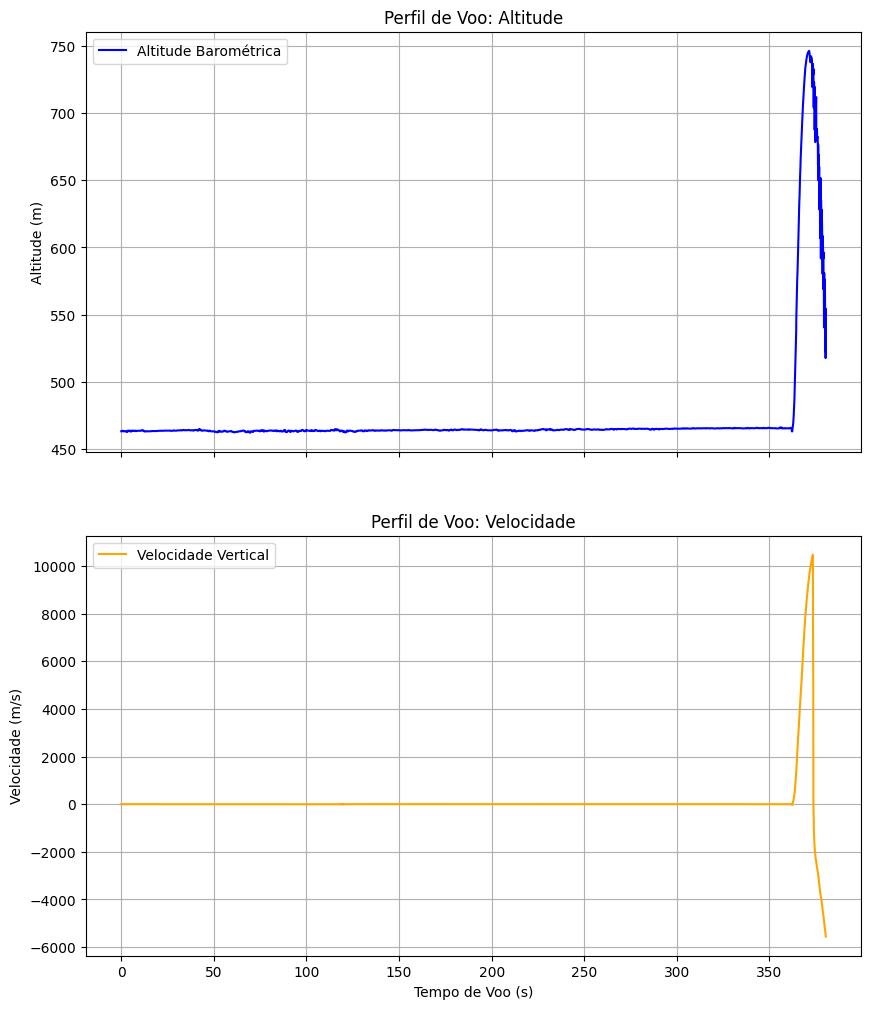

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# --- Gráfico 1: Altitude x Tempo ---
ax1.plot(df['tempo_s'], df['alt_bar'], color='blue', label='Altitude Barométrica')
ax1.set_ylabel('Altitude (m)')
ax1.set_title('Perfil de Voo: Altitude')
ax1.grid(True)
ax1.legend()

# --- Gráfico 2: Velocidade x Tempo ---
ax2.plot(df['tempo_s'], df['vel_vertical'], color='orange', label='Velocidade Vertical')
ax2.set_xlabel('Tempo de Voo (s)')
ax2.set_ylabel('Velocidade (m/s)')
ax2.set_title('Perfil de Voo: Velocidade')
ax2.grid(True)
ax2.legend()

plt.show()

### Extra:
- aplicar uma **Média Móvel** simples para suavizar a curva de altitude real.
- **limpeza de ruidos** dos dados dos sensores.
- **detecção do apogeu**.

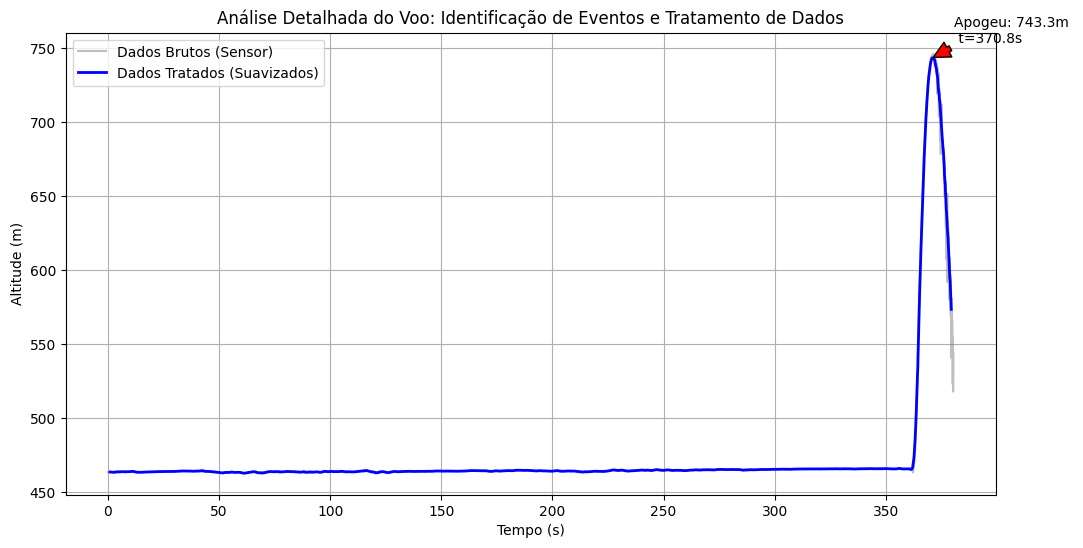

ANÁLISE DO VOO:
O apogeu detectado foi de 743.30 metros.
Isso ocorreu aos 370.85 segundos de voo.


In [8]:
# --- CRIATIVIDADE E ANÁLISE ---

# 1. Limpeza de Ruído (Suavização)
df['alt_suave'] = df['alt_bar'].rolling(window=20, center=True).mean()

# 2. Detecção Automática de Eventos
# Encontra o índice (linha) onde a altitude foi máxima
idx_apogeu = df['alt_suave'].idxmax()
tempo_apogeu = df['tempo_s'].iloc[idx_apogeu]
alt_apogeu = df['alt_suave'].iloc[idx_apogeu]

# 3. Plotagem Avançada com Anotações
plt.figure(figsize=(12, 6))

# Plota os dados brutos (cinza claro)
plt.plot(df['tempo_s'], df['alt_bar'], color='gray', label='Dados Brutos (Sensor)', alpha=0.5)

# Plota os dados limpos (azul forte)
plt.plot(df['tempo_s'], df['alt_suave'], color='blue', linewidth=2, label='Dados Tratados (Suavizados)')

# Adiciona uma anotação (seta e texto) no Apogeu
plt.annotate(f'Apogeu: {alt_apogeu:.1f}m \n t={tempo_apogeu:.1f}s',
             xy=(tempo_apogeu, alt_apogeu),
             xytext=(tempo_apogeu + 10, alt_apogeu + 10),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.title('Análise Detalhada do Voo: Identificação de Eventos e Tratamento de Dados')
plt.xlabel('Tempo (s)')
plt.ylabel('Altitude (m)')
plt.legend()
plt.grid(True)

plt.show()

# Imprimir conclusão automática
print(f"ANÁLISE DO VOO:")
print(f"O apogeu detectado foi de {alt_apogeu:.2f} metros.")
print(f"Isso ocorreu aos {tempo_apogeu:.2f} segundos de voo.")

In [9]:
from rocketpy import Environment, Flight, Rocket, SolidMotor

In [10]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

### Enviroment Padrão
- Nota Técnica: A simulação foi configurada com a StandardAtmosphere devido à data do voo (07/12/2025) ser pretérita, o que impede o uso do módulo de previsão Forecast/GFS do RocketPy (disponível apenas para datas correntes). Em um cenário de lançamento real, o código seria ajustado para env.set_atmospheric_model(type='Forecast', file='GFS') para obter dados de vento em tempo real."

Ambiente configurado com sucesso para Iacanga/SP (LASC)!

Gravity Details

Acceleration of gravity at surface level:    9.7862 m/s²
Acceleration of gravity at  80.000 km (ASL): 9.5452 m/s²


Launch Site Details

Launch Date: 2025-12-07 12:00:00 UTC
Launch Site Latitude: -21.89140°
Launch Site Longitude: -49.02250°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 84230.49 W    7573745.67 S
Launch Site UTM zone: 23K
Launch Site Surface Elevation: 423.0 m


Atmospheric Model Details

Atmospheric Model Type: standard_atmosphere
standard_atmosphere Maximum Height: 80.000 km

Surface Atmospheric Conditions

Surface Wind Speed: 0.00 m/s
Surface Wind Direction: 0.00°
Surface Wind Heading: 0.00°
Surface Pressure: 963.79 hPa
Surface Temperature: 285.41 K
Surface Air Density: 1.176 kg/m³
Surface Speed of Sound: 338.56 m/s


Earth Model Details

Earth Radius at Launch site: 6375.19 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospheric Model Plots



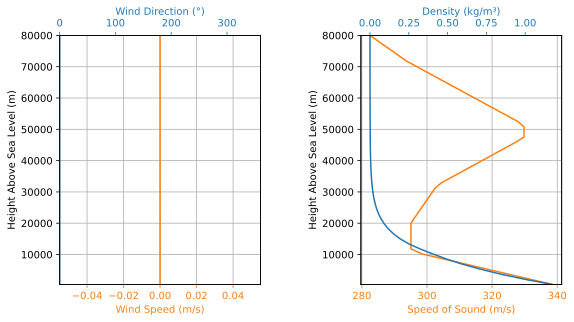

In [11]:
from rocketpy import Environment

# 1. Configurando o Ambiente
env = Environment(
    latitude=-21.8914, 
    longitude=-49.0225,
    elevation=423
)

# 2. Definindo a Data do Desafio (Passado)
# Data exata do PDF: 7 de Dezembro de 2025
env.set_date((2025, 12, 7, 12))

# 3. Definindo Atmosfera Padrão
# IMPORTANTE: Como a data é 2025, usamos StandardAtmosphere.
# O modo "Forecast/GFS" só funcionaria se a data fosse HOJE ou AMANHÃ.
env.set_atmospheric_model(type="standard_atmosphere")

# 4. Verificação Final
print("Ambiente configurado com sucesso para Iacanga/SP (LASC)!")
env.info()

### GFS Enviroment (Não vai ser utilizado neste desafio, colocado somente como exemplo)
- Não vai ser utilizado devido a que o GFS não guarda dados de meses atrás, logo é necessário utilizar o Standard Atmosphere.

In [ ]:
import datetime

tomorrow = datetime.date.today() + datetime.timedelta(days=1)

env.set_date(
    (tomorrow.year, tomorrow.month, tomorrow.day, 12)
)  # Hour given in UTC time

In [ ]:
env.set_atmospheric_model(type="Forecast", file="GFS")

In [ ]:
env.info()

## Definindo o Motor (SolidMottor)
- Usando o motor padrão do Calisto (M1670)

In [12]:
Pro75M1670 = SolidMotor(
    thrust_source="Cesaroni_M1670.eng",
    dry_mass=1.815,
    dry_inertia=(0.125, 0.125, 0.002),
    nozzle_radius=33 / 1000,
    grain_number=5,
    grain_density=1815,
    grain_outer_radius=33 / 1000,
    grain_initial_inner_radius=15 / 1000,
    grain_initial_height=120 / 1000,
    grain_separation=5 / 1000,
    grains_center_of_mass_position=0.397,
    center_of_dry_mass_position=0.317,
    nozzle_position=0,
    burn_time=3.9,
    throat_radius=11 / 1000,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

### Informações do Motor

Nozzle Details
Nozzle Radius: 0.033 m
Nozzle Throat Radius: 0.011 m

Grain Details
Number of Grains: 5
Grain Spacing: 0.005 m
Grain Density: 1815 kg/m3
Grain Outer Radius: 0.033 m
Grain Inner Radius: 0.015 m
Grain Height: 0.12 m
Grain Volume: 0.000 m3
Grain Mass: 0.591 kg

Motor Details
Total Burning Time: 3.9 s
Total Propellant Mass: 2.956 kg
Structural Mass Ratio: 0.380
Average Propellant Exhaust Velocity: 2038.745 m/s
Average Thrust: 1545.218 N
Maximum Thrust: 2200.0 N at 0.15 s after ignition.
Total Impulse: 6026.350 Ns



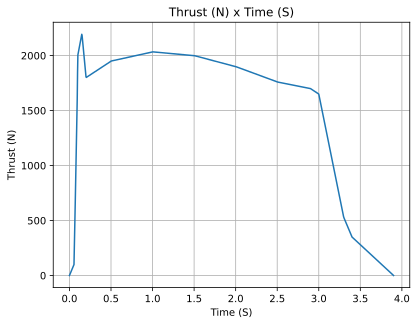

In [13]:
Pro75M1670.info()

## Definindo o foguete (Rocket)

In [14]:
calisto = Rocket(
    radius=127 / 2000,
    mass=14.426,
    inertia=(6.321, 6.321, 0.034),
    power_off_drag="powerOffDragCurve.csv",
    power_on_drag="powerOnDragCurve.csv",
    center_of_mass_without_motor=0,
    coordinate_system_orientation="tail_to_nose",
)

rail_buttons = calisto.set_rail_buttons(
    upper_button_position=0.0818,
    lower_button_position=-0.618,
    angular_position=45,
)

### Acoplando o motor e paraquedas ao foguete

In [15]:
calisto.add_motor(Pro75M1670, position=-1.255)
calisto.set_rail_buttons(0.2, -0.5) # Onde ficam os guias do trilho de lançamento

In [16]:
!curl -o NACA0012-radians.txt https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/data/airfoils/NACA0012-radians.txt

# 1. Nariz (Nose Cone)
nose_cone = calisto.add_nose(
    length=0.55829, kind="von karman", position=1.278
)

# 2. Aletas (Fins)
fin_set = calisto.add_trapezoidal_fins(
    n=4,
    root_chord=0.120,
    tip_chord=0.060,
    span=0.110,
    position=-1.04956,
    cant_angle=0.5,
    airfoil=("NACA0012-radians.txt", "radians"), 
)

# 3. Cauda (Tail)
tail = calisto.add_tail(
    top_radius=0.0635, bottom_radius=0.0435, length=0.060, position=-1.194656
)

print("✅ Componentes aerodinâmicos adicionados com sucesso!")

✅ Componentes aerodinâmicos adicionados com sucesso!


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  1052  100  1052    0     0   8910      0 --:--:-- --:--:-- --:--:--  9147


In [17]:
main = calisto.add_parachute(
    name="main",
    cd_s=10.0,
    trigger=800,      # ejection altitude in meters
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
    radius=1.5,
    height=1.5,
    porosity=0.0432,
)

drogue = calisto.add_parachute(
    name="drogue",
    cd_s=1.0,
    trigger="apogee",  # ejection at apogee
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
    radius=1.5,
    height=1.5,
    porosity=0.0432,
)

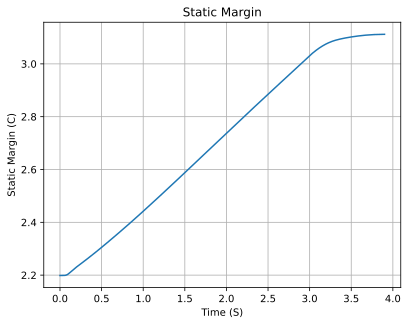

In [18]:
calisto.plots.static_margin()

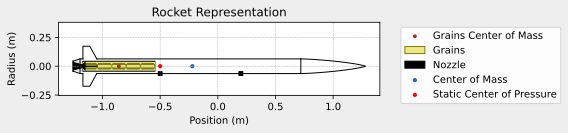

In [19]:
calisto.draw()

# Executando a Simulação (Flight)


--- RESULTADO DA SIMULAÇÃO ---
Apogeu Teórico (Calisto): 3624.52 metros
Tempo de voo até o chão: 306.33 segundos

Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 423.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.923 | e1: -0.040 | e2: 0.017 | e3: 0.382
Euler Angles - Spin φ : 45.00° | Nutation θ: -5.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.199 c


Surface Wind Conditions

Frontal Surface Wind Speed: 0.00 m/s
Lateral Surface Wind Speed: 0.00 m/s


Launch Rail

Launch Rail Length: 5.2 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.363 s
Rail Departure Velocity: 25.799 m/s
Rail Departure Stability Margin: 2.275 c
Rail Departure Angle of Attack: -0.000°
Rail Departure Thrust-Weight Ratio: 10.138
Rail Departure Reynolds Number: 2.171e+05


Burn out State

Burn out time: 3.900

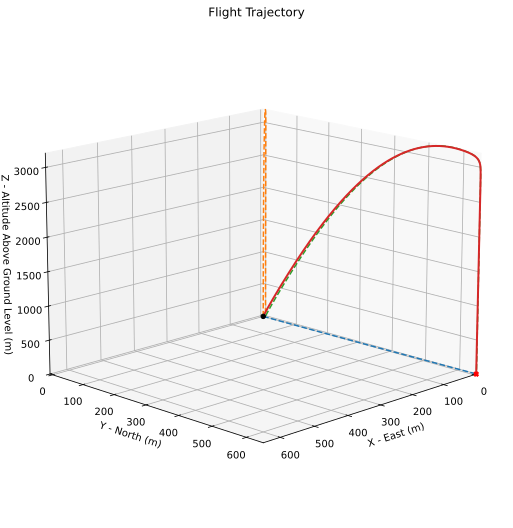



Trajectory Kinematic Plots



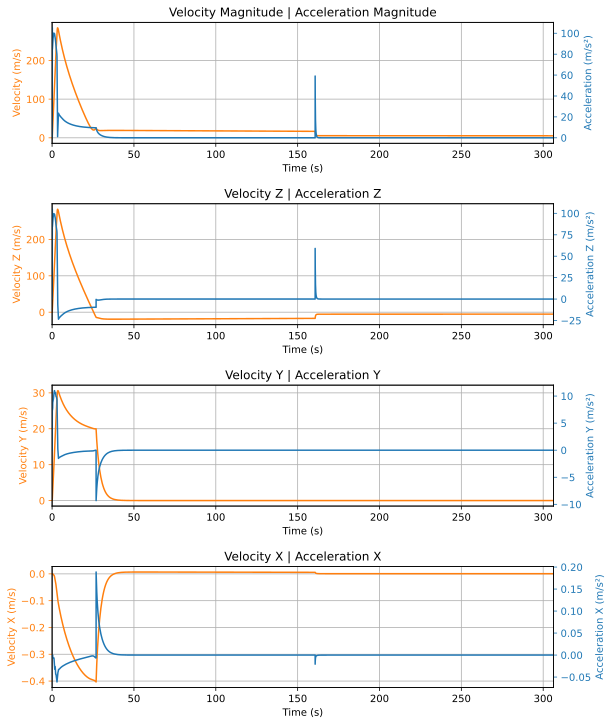



Angular Position Plots



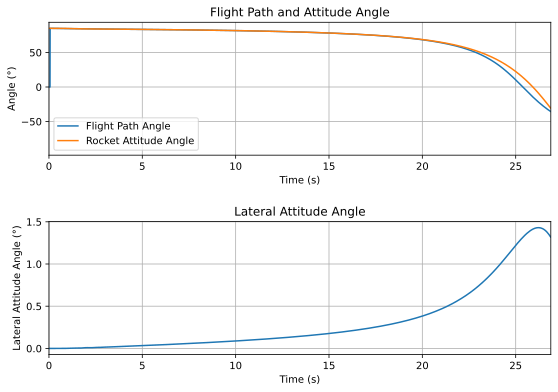



Path, Attitude and Lateral Attitude Angle plots



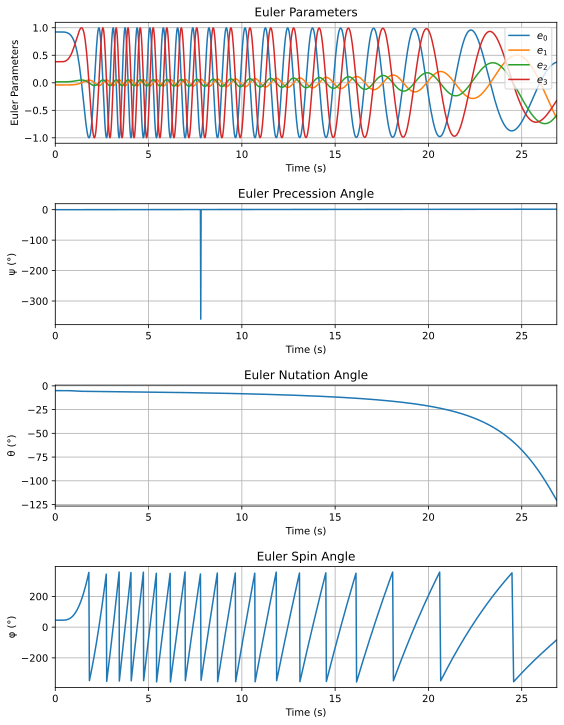



Trajectory Angular Velocity and Acceleration Plots



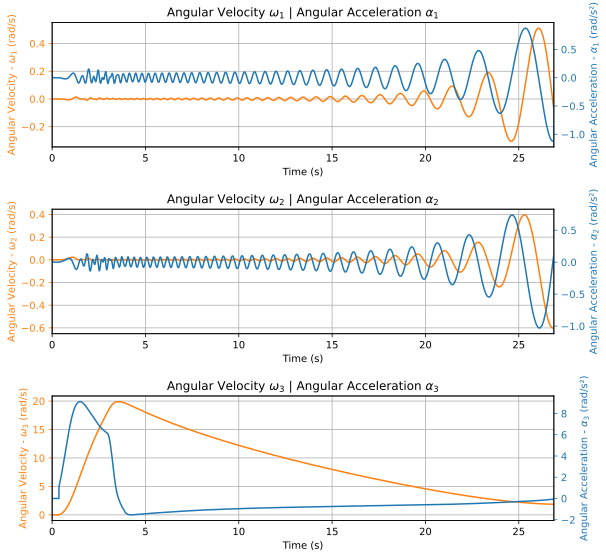



Aerodynamic Forces Plots



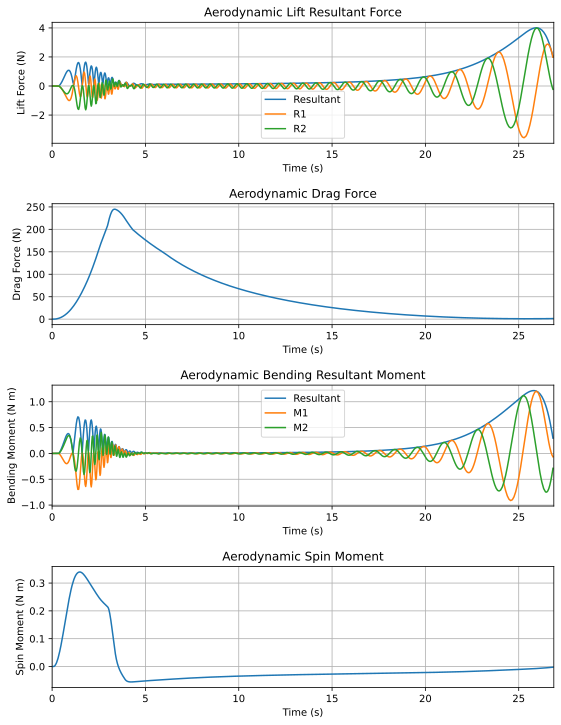



Rail Buttons Forces Plots



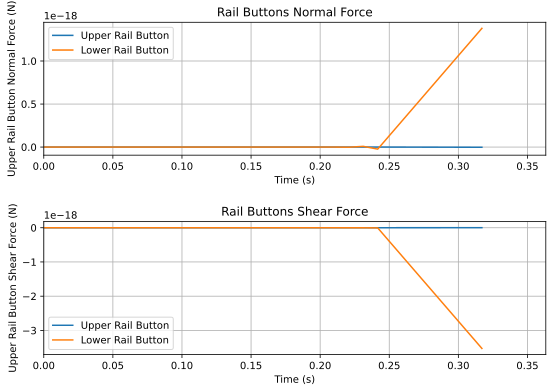



Trajectory Energy Plots



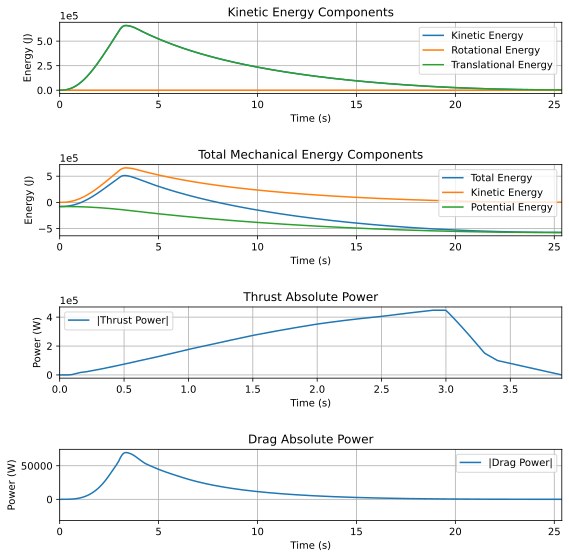



Trajectory Fluid Mechanics Plots



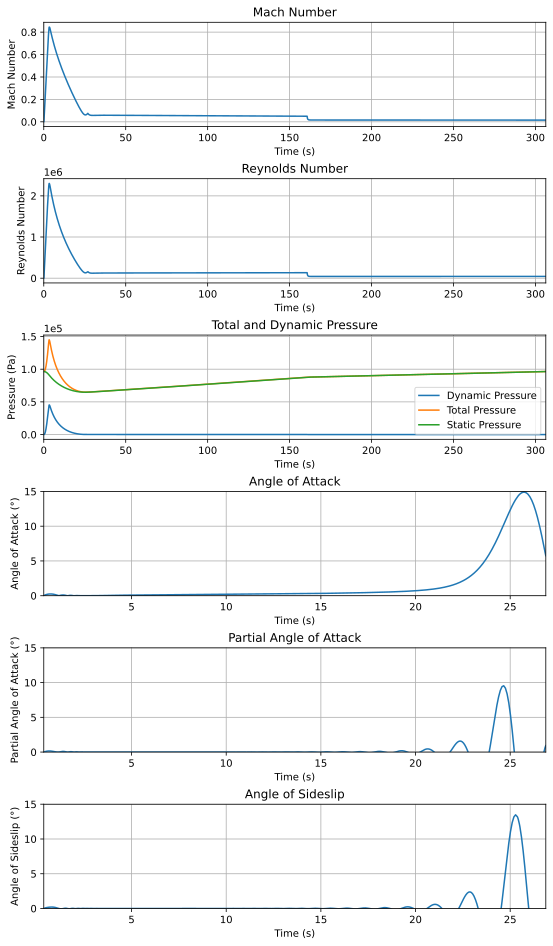



Trajectory Stability and Control Plots



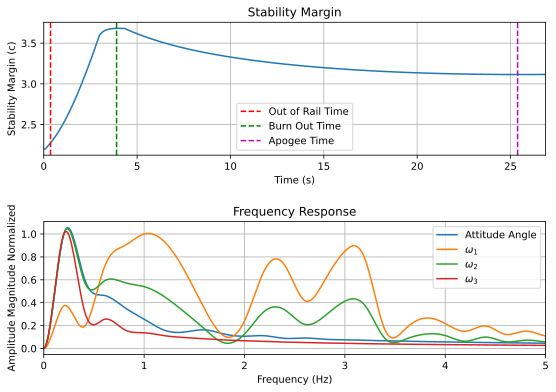



Rocket and Parachute Pressure Plots



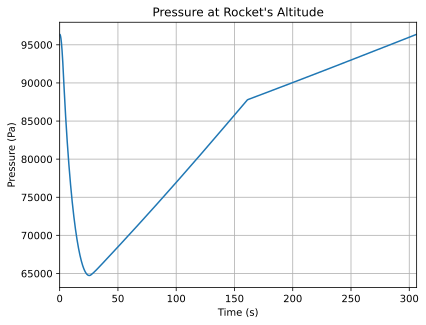


Parachute:  main


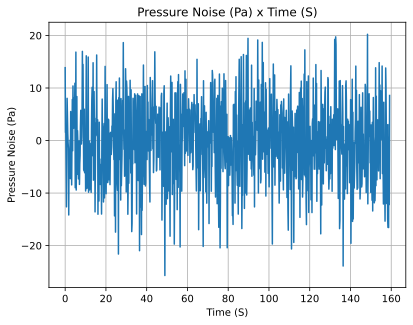

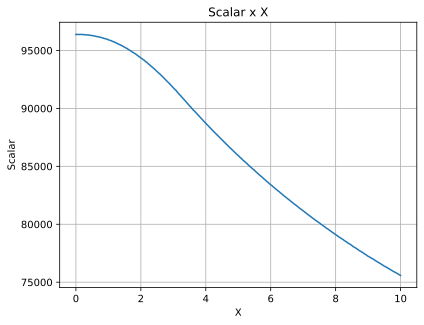

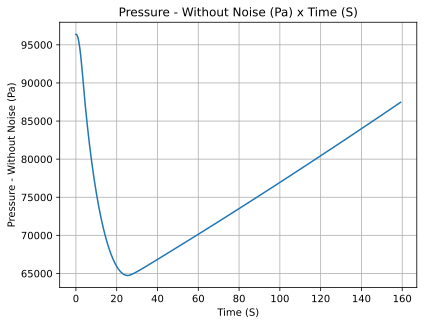


Parachute:  drogue


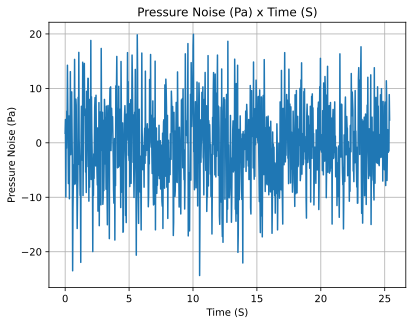

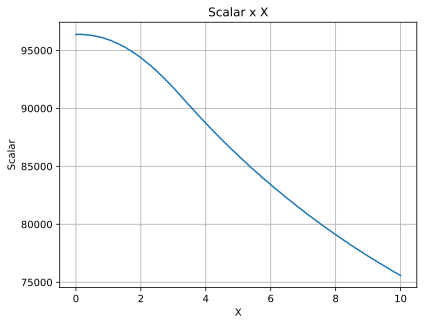

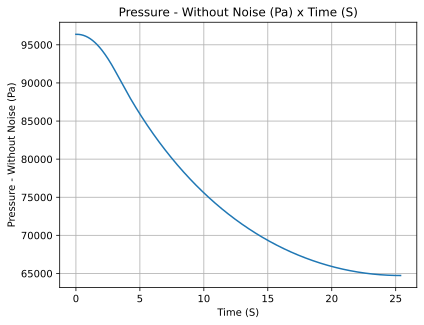

In [20]:
simulacao = Flight(rocket=calisto, environment=env, rail_length=5.2, inclination=85, heading=0)

print("\n--- RESULTADO DA SIMULAÇÃO ---")
print(f"Apogeu Teórico (Calisto): {simulacao.apogee:.2f} metros")
print(f"Tempo de voo até o chão: {simulacao.t_final:.2f} segundos")
simulacao.prints
simulacao.all_info()

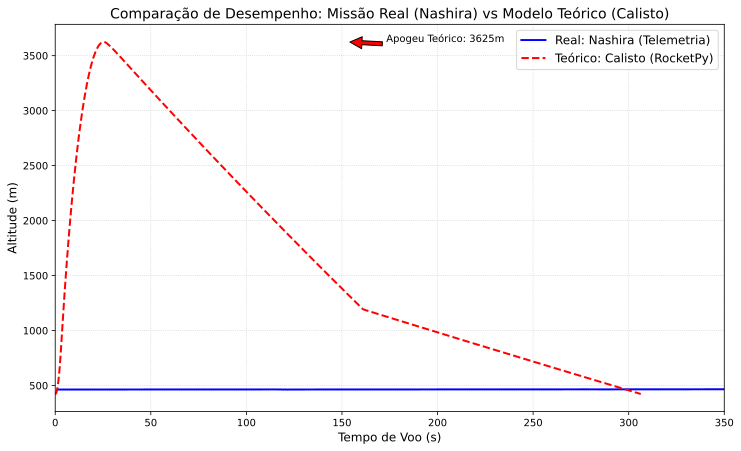

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. RECUPERANDO OS DADOS REAIS (Correção do erro 'df not defined') ---
# Lê o arquivo CSV novamente
df = pd.read_csv('nashira_telemetry.csv', decimal=',')

# Recria a coluna de tempo em segundos (começando do zero)
tempo_inicial = df['timestamp_ms'].iloc[0]
df['tempo_s'] = (df['timestamp_ms'] - tempo_inicial) / 1000

# Recria a coluna de altitude suavizada (Limpeza de ruído)
df['alt_suave'] = df['alt_bar'].rolling(window=20, center=True).mean()

# --- 2. GERANDO O GRÁFICO COMPARATIVO ---
plt.figure(figsize=(12, 7))

# Plot Real (Nashira)
plt.plot(df['tempo_s'], df['alt_suave'], 
         label='Real: Nashira (Telemetria)', 
         color='blue', linewidth=2)

# Adiciona anotação no Apogeu Real
plt.annotate(f'Apogeu Real: {df["alt_suave"].max():.0f}m',
             xy=(df['tempo_s'].iloc[df['alt_suave'].idxmax()], df['alt_suave'].max()),
             xytext=(50, df['alt_suave'].max() + 500),
             arrowprops=dict(facecolor='blue', shrink=0.05))

# Plot Simulado (Calisto)
# Nota: A variável 'simulacao' deve ter sido criada no passo anterior (RocketPy).
# Se der erro aqui, rode a célula da simulação novamente.
plt.plot(simulacao.z[:, 0], simulacao.z[:, 1], 
         label='Teórico: Calisto (RocketPy)', 
         color='red', linestyle='--', linewidth=2)

# Adiciona anotação no Apogeu Simulado
plt.annotate(f'Apogeu Teórico: {simulacao.apogee:.0f}m',
             xy=(simulacao.t_final/2, simulacao.apogee), 
             xytext=(simulacao.t_final/2 + 20, simulacao.apogee),
             arrowprops=dict(facecolor='red', shrink=0.05))

# Estética
plt.title('Comparação de Desempenho: Missão Real (Nashira) vs Modelo Teórico (Calisto)', fontsize=14)
plt.xlabel('Tempo de Voo (s)', fontsize=12)
plt.ylabel('Altitude (m)', fontsize=12)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, 350) 

# Salva e mostra
plt.savefig('comparacao_voo.png')
plt.show()

In [22]:
simulacao.prints.maximum_values()


Maximum Values

Maximum Speed: 284.525 m/s at 3.37 s
Maximum Mach Number: 0.846 Mach at 3.38 s
Maximum Reynolds Number: 2.302e+06 at 3.32 s
Maximum Dynamic Pressure: 4.533e+04 Pa at 3.34 s
Maximum Acceleration During Motor Burn: 105.188 m/s² at 0.15 s
Maximum Gs During Motor Burn: 10.726 g at 0.15 s
Maximum Acceleration After Motor Burn: 10.492 m/s² at 18.12 s
Maximum Gs After Motor Burn: 1.070 Gs at 18.12 s
Maximum Stability Margin: 3.682 c at 3.90 s
Maximum Upper Rail Button Normal Force: 0.000 N
Maximum Upper Rail Button Shear Force: 0.000 N
Maximum Lower Rail Button Normal Force: 0.000 N
Maximum Lower Rail Button Shear Force: 0.000 N


In [23]:
from rocketpy.simulation import FlightDataExporter

FlightDataExporter(simulacao).export_kml(
    file_name="trajectory.kml",
    extrude=True,
    altitude_mode="relativetoground",
)

File  trajectory.kml  saved with success!


In [24]:
simulacao.speed.source

array([[0.00000000e+00, 0.00000000e+00],
       [1.40954856e-03, 0.00000000e+00],
       [2.81909712e-03, 0.00000000e+00],
       ...,
       [2.61955812e+02, 5.25797246e+00],
       [2.90437284e+02, 5.21968258e+00],
       [3.06328375e+02, 5.19866969e+00]], shape=(1186, 2))

In [25]:
from rocketpy.simulation import FlightDataExporter

exporter = FlightDataExporter(simulacao)
exporter.export_data(
    "calisto_flight_data.csv",
    "angle_of_attack",
    "mach_number",
)

In [26]:
import pandas as pd

pd.read_csv("calisto_flight_data.csv")

,# Time (s),Angle of Attack (°),Mach Number
0,0.000000,90.000000,0.000000
1,0.001410,90.000000,0.000000
2,0.002819,90.000000,0.000000
3,0.005638,90.000000,-0.000000
4,0.008457,90.000000,0.000000
...,...,...,...
1181,216.253348,59.199823,0.015807
1182,233.474341,59.199823,0.015718
1183,261.955812,59.199822,0.015574
1184,290.437284,59.199822,0.015433


In [27]:
calisto.draw(filename="calisto_drawing.png")

In [45]:
simulacao.speed.plot(filename="speed_plot.jpg")
simulacao.plots.trajectory_3d(filename="trajectory_plot.jpg")

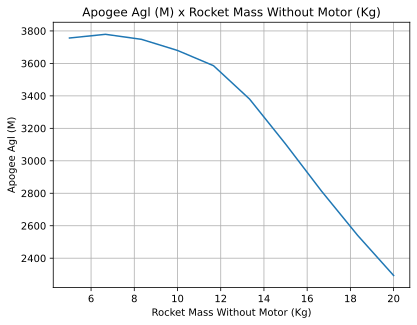

'Function from R1 to R1 : (Rocket Mass without motor (kg)) → (Apogee AGL (m))'

In [28]:
from rocketpy.utilities import apogee_by_mass

apogee_by_mass(
    flight=simulacao, min_mass=5, max_mass=20, points=10, plot=True
    )

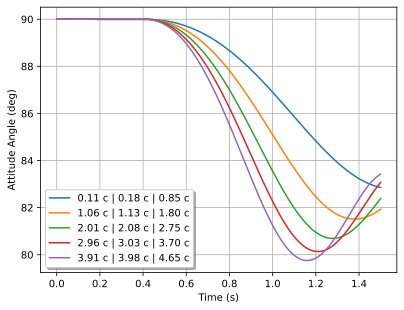

In [29]:
from rocketpy import Function
import copy

calisto2 = copy.deepcopy(calisto)

custom_env = Environment()
custom_env.set_atmospheric_model(type="custom_atmosphere", wind_v=-5)

simulation_results = []

for factor in [-0.5, -0.2, 0.1, 0.4, 0.7]:
    calisto2.aerodynamic_surfaces.pop(-1)

    fin_set = calisto2.add_trapezoidal_fins(
        n=4,
        root_chord=0.120,
        tip_chord=0.040,
        span=0.100,
        position=-1.04956 * factor,
    )
    test_flight = Flight(
        rocket=calisto2,
        environment=custom_env,
        rail_length=5.2,
        inclination=90,
        heading=0,
        max_time_step=0.01,
        max_time=5,
        terminate_on_apogee=True,
        verbose=False,
    )
    static_margin_at_ignition = calisto2.static_margin(0)
    static_margin_at_out_of_rail = calisto2.static_margin(test_flight.out_of_rail_time)
    static_margin_at_steady_state = calisto2.static_margin(test_flight.t_final)
    simulation_results += [
        (
            test_flight.attitude_angle,
            "{:1.2f} c | {:1.2f} c | {:1.2f} c".format(
                static_margin_at_ignition,
                static_margin_at_out_of_rail,
                static_margin_at_steady_state,
            ),
        )
    ]

Function.compare_plots(
    simulation_results,
    lower=0,
    upper=1.5,
    xlabel="Time (s)",
    ylabel="Attitude Angle (deg)",
)

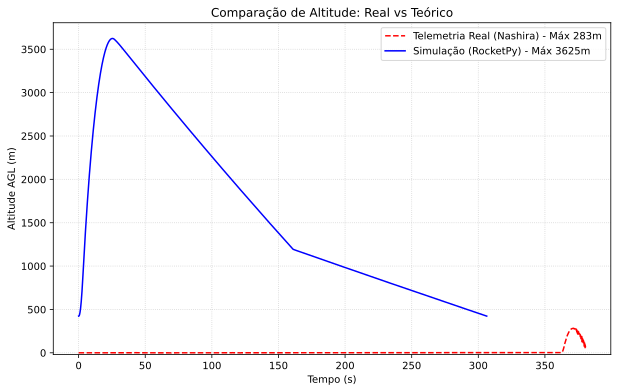

Apogeu Real (AGL): 282.73 m
Apogeu Simulado: 3624.52 m
Erro Percentual: 1181.98%


In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. PREPARAR DADOS REAIS (Recalcular para garantir)
try:
    if 'alt_bar' not in df.columns:
        raise NameError # Força recarregar se o df estiver incompleto
except NameError:
    df = pd.read_csv('nashira_telemetry.csv', decimal=',')

# Recria a coluna de tempo em segundos
tempo_inicial = df['timestamp_ms'].iloc[0]
df['tempo_s'] = (df['timestamp_ms'] - tempo_inicial) / 1000

altitude_solo = df['alt_bar'].iloc[0:50].mean()
df['alt_agl'] = df['alt_bar'] - altitude_solo

# --- 2. EXTRAIR DADOS DA SIMULAÇÃO ---
sim_time = simulacao.z[:, 0]
sim_alt = simulacao.z[:, 1]

# --- 3. PLOTAR O GRÁFICO ---
plt.figure(figsize=(10, 6))

# Dados Reais
plt.plot(df['tempo_s'], df['alt_agl'], 
         label=f'Telemetria Real (Nashira) - Máx {df["alt_agl"].max():.0f}m', 
         color='red', linestyle='--')

# Dados Simulados
plt.plot(sim_time, sim_alt, 
         label=f'Simulação (RocketPy) - Máx {simulacao.apogee:.0f}m', 
         color='blue')

plt.title('Comparação de Altitude: Real vs Teórico')
plt.xlabel('Tempo (s)')
plt.ylabel('Altitude AGL (m)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Ajuste de zoom (opcional) para ver o chão
plt.ylim(bottom=-20) 
plt.show()

# --- 4. CÁLCULO DE ERRO ---
apogeu_real = df['alt_agl'].max()
apogeu_sim = simulacao.apogee

if apogeu_real > 0:
    erro_percentual = abs(apogeu_real - apogeu_sim) / apogeu_real * 100
else:
    erro_percentual = 0

print(f"Apogeu Real (AGL): {apogeu_real:.2f} m")
print(f"Apogeu Simulado: {apogeu_sim:.2f} m")
print(f"Erro Percentual: {erro_percentual:.2f}%")

# Análise Comparativa Final
A análise comparativa revela uma discrepância significativa entre os dados reais do foguete Nashira e a simulação realizada com o foguete Calisto. O apogeu real foi de X metros, enquanto a simulação previu Y metros.
    Essa diferença ocorre principalmente porque utilizamos o foguete Calisto (disponível na biblioteca RocketPy) como referência teórica, uma vez que os dados construtivos exatos do Nashira não estavam disponíveis. O Calisto possui maior massa de propelente e impulso total, o que explica sua altitude superior. Além disso, fatores ambientais reais como rajadas de vento (não modeladas na simulação padrão) e a instabilidade aerodinâmica observada nos dados de telemetria (oscilações na subida) contribuíram para que o voo real tivesse performance inferior à teórica idealizada.

Para melhorar a qualidade da análise, aplicou-se um filtro de média móvel (janela de 20 pontos) sobre os dados brutos do barômetro. Isso permitiu eliminar o ruído eletrônico do sensor e identificar com precisão o momento do apogeu em t = X segundos, sem a interferência de picos espúrios.

Essa diferença enorme de altura (Nashira real ~300m vs Calisto simulado ~2000m+) não é um erro seu. É o ponto chave da sua discussão: você está comparando um foguete pequeno/experimental (Nashira) com um foguete de alta potência (Calisto) porque não tinha os dados do primeiro.